# Error by Geography - 500 Epoch Linear Scaling (IoD 2025, England Only)

This notebook analyses reconstruction error by geography using the **500-epoch linear scaling**
retraining stability runs (`retraining_stability_500epochs_linscaling`).

**Key differences from notebook 5:**
- Uses **English IoD 2025** (via LSOA 2021 codes) instead of UK IMD 2019
- Restricts analysis to **England-only OAs** (~175k vs 188k)
- Includes **Global RMSE** plots alongside mean RMSE plots

**Approach:**
1. Load reconstruction errors from all retraining runs (500 epochs, linear scaling)
2. Identify the run with the median overall RMSE
3. Filter to England-only OAs
4. Use the median run's errors (plus PCA) for geographic analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import pickle
import os
from textwrap import fill

# Set style
sns.set(style="white")

# Configuration
bottleneck = 100  # Focus on 100D
run_selection = "median"  # "median" to auto-select median run, or an int (e.g. 0, 3, 7) to pick a specific run

print(f"Analyzing reconstruction error by geography (500 epochs, linear scaling)")
print(f"Bottleneck dimension: {bottleneck}")
print(f"Run selection: {run_selection}")

Analyzing reconstruction error by geography (500 epochs, linear scaling)
Bottleneck dimension: 100
Run selection: median


## 1. Load Auxiliary Geographic Data

In [2]:
# Load the lookup tables — use the 2021 lookup for LSOA21CD (needed for IoD 2025)
oa_lookup = pd.read_csv(
    '../data/geofiles/Output_Area_to_Lower_layer_Super_Output_Area_to_Middle_layer_Super_Output_Area_to_Local_Authority_District_(December_2021)_Lookup_in_England_and_Wales_v3.csv',
    usecols=["OA21CD", "LSOA21CD", "MSOA21CD"],
    low_memory=False
).set_index('OA21CD')

# Load IoD 2025 (England only, LSOA 2021 codes)
iod = pd.read_csv('../data/geofiles/IoD2025_File7_all.csv')
iod = iod[["LSOA code (2021)", "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)"]]
iod.columns = ['LSOA21CD', 'IMD']

# Load the population density data
density = pd.read_csv('../data/census_data/eng_raw_csvs/ts006.csv')
density.columns = ['OA21CD', 'Density']
density['Density_decile'] = pd.qcut(density['Density'], 10, labels=False)
density['Density_decile'] = 10 - density['Density_decile']  # reverse the order
density.drop('Density', axis=1, inplace=True)
density.set_index('OA21CD', inplace=True)

print(f"Loaded OA→LSOA21/MSOA21 lookup: {len(oa_lookup)} rows")
print(f"Loaded IoD 2025 data: {len(iod)} rows")
print(f"Loaded density data: {len(density)} rows")

Loaded OA→LSOA21/MSOA21 lookup: 188880 rows
Loaded IoD 2025 data: 33755 rows
Loaded density data: 188880 rows


In [3]:
# Load OAC data
OAC = pd.read_csv("../data/OAC/OAC_assignment.csv")
OAC = OAC[["Geography_Code", "Supergroup8", "Group", "Subgroup"]]
OAC = OAC.rename(columns={"Geography_Code": "OA21CD"})

# Load the OAC category names
OAC_cats = pd.read_csv("../data/OAC/OAC_cats.csv")
OAC_cats = OAC_cats[['Classification Code', 'Classification Name']]

# Make a dict out of the first 8 rows
OAC_cats_dict = OAC_cats.set_index('Classification Code')['Classification Name'].to_dict()

# Convert codes to string before mapping
OAC['Supergroup8'] = OAC['Supergroup8'].astype(str)
OAC['Supergroup_name'] = OAC['Supergroup8'].map(OAC_cats_dict)
OAC['Supergroup_codename'] = OAC['Supergroup8'] + " - " + OAC['Supergroup_name']
OAC['Group'] = OAC['Group'].astype(str)
OAC['Group_name'] = OAC['Group'].map(OAC_cats_dict)
OAC['Subgroup'] = OAC['Subgroup'].astype(str)
OAC['Subgroup_name'] = OAC['Subgroup'].map(OAC_cats_dict)

print(f"Loaded OAC data: {len(OAC)} rows")
print(f"Unique supergroups: {OAC['Supergroup_codename'].nunique()}")

Loaded OAC data: 239768 rows
Unique supergroups: 8


## 2. Load Stability Results and Identify Median-Error Run

In [4]:
# Load the stability results (500 epochs, linear scaling)
stability_path = f"../AE_outputs/retraining_stability_500epochs_linscaling/data/stability_checkpoint_{bottleneck}d.pkl"

with open(stability_path, 'rb') as f:
    checkpoint = pickle.load(f)

print(f"Loaded checkpoint for {bottleneck}D (500 epochs, linear scaling)")
print(f"Keys: {checkpoint.keys()}")
print(f"Number of runs: {checkpoint['n_runs']}")

# Get the reconstruction errors - these are MSE per OA
reco_errors_list = checkpoint['reco_errors_list']
print(f"Shape of reco errors for run 0: {reco_errors_list[0].shape}")

Loaded checkpoint for 100D (500 epochs, linear scaling)
Keys: dict_keys(['bottleneck_size', 'embeddings_list', 'reco_errors_list', 'n_runs'])
Number of runs: 10
Shape of reco errors for run 0: (188880,)


In [5]:
# Compute overall RMSE for each run and find the median
n_runs = checkpoint['n_runs']
rmse_per_run = []
mean_oa_rmse_per_run = []
for run_idx, reco_err in enumerate(reco_errors_list):
    # MSE to Global RMSE
    global_rmse = np.sqrt(reco_err.mean())
    # Mean per-OA RMSE
    mean_oa_rmse = np.sqrt(reco_err).mean()
    rmse_per_run.append(global_rmse)
    mean_oa_rmse_per_run.append(mean_oa_rmse)
    print(f"Run {run_idx}: Global RMSE = {global_rmse*100:.4f}%  |  Mean per-OA RMSE = {mean_oa_rmse*100:.4f}%")

rmse_per_run = np.array(rmse_per_run)
mean_oa_rmse_per_run = np.array(mean_oa_rmse_per_run)

# Find the median run
median_rmse = np.median(rmse_per_run)
median_run_idx = np.argmin(np.abs(rmse_per_run - median_rmse))

# Select the run based on run_selection parameter
if run_selection == "median":
    selected_run_idx = median_run_idx
    run_label = f"median (Run {selected_run_idx})"
else:
    selected_run_idx = int(run_selection)
    assert 0 <= selected_run_idx < n_runs, f"run_selection={selected_run_idx} out of range [0, {n_runs})"
    run_label = f"Run {selected_run_idx}"

print(f"\nGlobal RMSE:      {rmse_per_run.mean()*100:.4f}% ± {rmse_per_run.std()*100:.4f}%")
print(f"Mean per-OA RMSE: {mean_oa_rmse_per_run.mean()*100:.4f}% ± {mean_oa_rmse_per_run.std()*100:.4f}%")
print(f"Median Global RMSE: {median_rmse*100:.4f}% (Run {median_run_idx})")
print(f"\n>>> Using {run_label} (RMSE = {rmse_per_run[selected_run_idx]*100:.4f}%)")

Run 0: Global RMSE = 0.8054%  |  Mean per-OA RMSE = 0.7743%
Run 1: Global RMSE = 0.7879%  |  Mean per-OA RMSE = 0.7554%
Run 2: Global RMSE = 0.7937%  |  Mean per-OA RMSE = 0.7614%
Run 3: Global RMSE = 0.7835%  |  Mean per-OA RMSE = 0.7519%
Run 4: Global RMSE = 0.7916%  |  Mean per-OA RMSE = 0.7593%
Run 5: Global RMSE = 0.7925%  |  Mean per-OA RMSE = 0.7598%
Run 6: Global RMSE = 0.7992%  |  Mean per-OA RMSE = 0.7663%
Run 7: Global RMSE = 0.7903%  |  Mean per-OA RMSE = 0.7578%
Run 8: Global RMSE = 0.7995%  |  Mean per-OA RMSE = 0.7656%
Run 9: Global RMSE = 0.7956%  |  Mean per-OA RMSE = 0.7628%

Global RMSE:      0.7939% ± 0.0060%
Mean per-OA RMSE: 0.7615% ± 0.0060%
Median Global RMSE: 0.7931% (Run 5)

>>> Using median (Run 5) (RMSE = 0.7925%)


In [6]:
# Load census data to get OA identifiers
cleaned_data_path = "../data/census_data/engcensus_cleaned_scaled.parquet"
data = pd.read_parquet(cleaned_data_path)
data = data.reset_index()

all_oa_ids = data['OA'].values
print(f"Total OAs in census data: {len(all_oa_ids)}")

# Verify lengths match
assert len(all_oa_ids) == len(reco_errors_list[0]), "OA count mismatch!"

# Filter to England-only OAs (codes starting with 'E')
eng_mask = np.array([oa.startswith('E') for oa in all_oa_ids])
eng_oa_ids = all_oa_ids[eng_mask]
eng_indices = np.where(eng_mask)[0]

n_wales = (~eng_mask).sum()
print(f"English OAs: {len(eng_oa_ids)}")
print(f"Welsh OAs dropped: {n_wales}")
assert n_wales > 0, "Expected some Welsh OAs to drop"
assert all(oa.startswith('E') for oa in eng_oa_ids), "Non-English OAs remain!"

Total OAs in census data: 188880
English OAs: 178605
Welsh OAs dropped: 10275


In [7]:
# Load PCA reconstruction for comparison
pca_path = f"../AE_outputs/engcensus_all/PCA/{bottleneck}_components.csv"
pca_reco = pd.read_csv(pca_path, index_col=0)

# Compute PCA reconstruction error (RMSE per OA)
pca_err_all = np.sqrt(np.mean((data.set_index("OA") - pca_reco) ** 2, axis=1)).reset_index()
pca_err_all.columns = ['OA21CD', 'pca_err']
pca_err_all['pca_err'] = pca_err_all['pca_err'] * 100  # Convert to percentage

# Filter to England-only
pca_err = pca_err_all[pca_err_all['OA21CD'].str.startswith('E')].reset_index(drop=True)

print(f"PCA reconstruction error computed (England only)")
print(f"Mean PCA RMSE: {pca_err['pca_err'].mean():.4f}%")
print(f"PCA OAs: {len(pca_err)}")

PCA reconstruction error computed (England only)
Mean PCA RMSE: 0.8972%
PCA OAs: 178605


In [8]:
# Compute Global RMSE and Mean per-OA RMSE for PCA (England only)
global_rmse_pca = np.sqrt(np.mean(pca_err['pca_err']**2))
mean_oa_rmse_pca = pca_err['pca_err'].mean()

# Recompute AE metrics for England-only OAs
rmse_per_run_eng = []
mean_oa_rmse_per_run_eng = []
for run_idx, reco_err_run in enumerate(reco_errors_list):
    eng_errs = reco_err_run[eng_indices]
    global_rmse = np.sqrt(eng_errs.mean())
    mean_oa_rmse = np.sqrt(eng_errs).mean()
    rmse_per_run_eng.append(global_rmse)
    mean_oa_rmse_per_run_eng.append(mean_oa_rmse)

rmse_per_run_eng = np.array(rmse_per_run_eng)
mean_oa_rmse_per_run_eng = np.array(mean_oa_rmse_per_run_eng)

# Print comparison table: all runs + PCA (England only)
print("=" * 70)
print("RMSE METRIC COMPARISON — ENGLAND ONLY (all values in %)")
print("=" * 70)
print(f"{'':25s} {'Global RMSE':>12s}  {'Mean per-OA':>12s}")
print(f"{'':25s} {'sqrt(mean(RMSE²))':>18s}  {'mean(RMSE)':>12s}")
print("-" * 70)
for i in range(n_runs):
    label = f"AE Run {i}"
    if i == selected_run_idx:
        label += " (selected)"
    if i == median_run_idx:
        label += " [median]"
    print(f"{label:<25s} {rmse_per_run_eng[i]*100:>11.4f}%  {mean_oa_rmse_per_run_eng[i]*100:>11.4f}%")
print("-" * 70)
print(f"{'AE (mean ± std)':<25s} {rmse_per_run_eng.mean()*100:>7.4f}±{rmse_per_run_eng.std()*100:.4f}%  {mean_oa_rmse_per_run_eng.mean()*100:>7.4f}±{mean_oa_rmse_per_run_eng.std()*100:.4f}%")
print(f"{'PCA':<25s} {global_rmse_pca:>11.4f}%  {mean_oa_rmse_pca:>11.4f}%")
print("-" * 70)

# Improvement vs PCA
print(f"\nImprovement vs PCA (selected: {run_label}):")
print(f"{'':25s} {'Global RMSE':>12s}  {'Mean per-OA':>12s}")
print(f"{'AE (selected) vs PCA':<25s} {(global_rmse_pca - rmse_per_run_eng[selected_run_idx]*100) / global_rmse_pca * 100:>11.2f}%  {(mean_oa_rmse_pca - mean_oa_rmse_per_run_eng[selected_run_idx]*100) / mean_oa_rmse_pca * 100:>11.2f}%")

RMSE METRIC COMPARISON — ENGLAND ONLY (all values in %)
                           Global RMSE   Mean per-OA
                           sqrt(mean(RMSE²))    mean(RMSE)
----------------------------------------------------------------------
AE Run 0                       0.8076%       0.7759%
AE Run 1                       0.7904%       0.7573%
AE Run 2                       0.7959%       0.7631%
AE Run 3                       0.7856%       0.7536%
AE Run 4                       0.7937%       0.7608%
AE Run 5 (selected) [median]      0.7950%       0.7618%
AE Run 6                       0.8013%       0.7679%
AE Run 7                       0.7932%       0.7603%
AE Run 8                       0.8017%       0.7673%
AE Run 9                       0.7979%       0.7646%
----------------------------------------------------------------------
AE (mean ± std)            0.7962±0.0059%   0.7633±0.0059%
PCA                            0.9478%       0.8972%
---------------------------------------------

In [9]:
# Create DataFrame using the SELECTED RUN errors (England only)
selected_reco_err = reco_errors_list[selected_run_idx]
eng_selected_reco_err = selected_reco_err[eng_indices]

# Convert MSE to RMSE and multiply by 100 for percentage
reco_err = pd.DataFrame({
    'OA21CD': eng_oa_ids,
    f'reco_err_{bottleneck}': np.sqrt(eng_selected_reco_err) * 100
})

# Normalize errors
reco_err[f'reco_err_{bottleneck}_norm'] = reco_err[f'reco_err_{bottleneck}'] / reco_err[f'reco_err_{bottleneck}'].mean() * 100

print(f"Created reconstruction error DataFrame using {run_label} (England only)")
print(f"Number of OAs: {len(reco_err)}")
print(f"Mean AE RMSE: {reco_err[f'reco_err_{bottleneck}'].mean():.4f}%")

Created reconstruction error DataFrame using median (Run 5) (England only)
Number of OAs: 178605
Mean AE RMSE: 0.7618%


In [10]:
# Prepare PCA error DataFrame (matching format)
pca_reco_err = pca_err.copy()
pca_reco_err.columns = ['OA21CD', f'pca_err_{bottleneck}']
pca_reco_err[f'pca_err_{bottleneck}_norm'] = pca_reco_err[f'pca_err_{bottleneck}'] / pca_reco_err[f'pca_err_{bottleneck}'].mean() * 100

# Compute percentage difference (median AE vs PCA) — align by OA
merged_check = reco_err.merge(pca_reco_err, on='OA21CD')
reco_err[f'perc_diff_{bottleneck}_ae'] = (reco_err[f'reco_err_{bottleneck}'].values - pca_reco_err[f'pca_err_{bottleneck}'].values) / pca_reco_err[f'pca_err_{bottleneck}'].values * 100

# Print comparison - Median AE vs PCA
n_median_ae_greater = len(reco_err[reco_err[f'reco_err_{bottleneck}'] > pca_reco_err[f'pca_err_{bottleneck}'].values])
print(f"Median AE - Number of OAs where AE > PCA: {n_median_ae_greater} out of {len(reco_err)} ({n_median_ae_greater / len(reco_err) * 100:.2f}%)")

Median AE - Number of OAs where AE > PCA: 4243 out of 178605 (2.38%)


In [11]:
# Merge with geographic metadata
reco_err = reco_err.merge(OAC, on="OA21CD", how="left")
pca_reco_err = pca_reco_err.merge(OAC, on="OA21CD", how="left")

# Add density deciles
reco_err = reco_err.merge(density, on="OA21CD", how="left")
pca_reco_err = pca_reco_err.merge(density, on="OA21CD", how="left")

# Add LSOA21CD and MSOA21CD from the 2021 lookup
reco_err = reco_err.merge(oa_lookup, on="OA21CD", how="left")
pca_reco_err = pca_reco_err.merge(oa_lookup, on="OA21CD", how="left")

reco_err = reco_err.dropna()

# Add IoD 2025 IMD decile (via LSOA21CD)
reco_err = reco_err.merge(iod, on="LSOA21CD", how="left").dropna()
pca_reco_err = pca_reco_err.merge(iod, on="LSOA21CD", how="left").dropna()

reco_err["IMD"] = reco_err["IMD"].astype(int)
pca_reco_err["IMD"] = pca_reco_err["IMD"].astype(int)

n_eng_oas = len(eng_oa_ids)
print(f"AE error DataFrame: {len(reco_err)} OAs (expected ~{n_eng_oas})")
print(f"PCA error DataFrame: {len(pca_reco_err)} OAs")
print(f"IMD NaN count (AE): {reco_err['IMD'].isna().sum()}")
print(f"IMD NaN count (PCA): {pca_reco_err['IMD'].isna().sum()}")

if len(reco_err) != len(pca_reco_err):
    print(f"WARNING: AE and PCA DataFrames have different lengths!")
elif len(reco_err) != n_eng_oas:
    print(f"WARNING: Expected {n_eng_oas} OAs but got {len(reco_err)}")
else:
    print(f"Data merged successfully: {len(reco_err)} England-only OAs")

AE error DataFrame: 178605 OAs (expected ~178605)
PCA error DataFrame: 178605 OAs
IMD NaN count (AE): 0
IMD NaN count (PCA): 0
Data merged successfully: 178605 England-only OAs


## 3. Plotting Functions (from notebook 4)

In [22]:
COL_AE = '#2b83ba'
COL_PCA = '#d7191c'

def _agg_fn(metric):
    """Return the appropriate aggregation function for the metric."""
    if metric == 'global_rmse':
        return lambda x: np.sqrt(np.mean(x**2))
    else:
        return 'mean'

def prepare_grouped_data(df1, df2, group_col, bottleneck, norm=False, metric='mean'):
    """Merge datasets and compute reconstruction error for each group.
    df1 contains AE errors; df2 contains PCA.
    metric: 'mean' for mean(RMSE), 'global_rmse' for sqrt(mean(RMSE²))"""

    if norm:
        ae_col = f"reco_err_{bottleneck}_norm"
        pca_col = f"pca_err_{bottleneck}_norm"
    else:
        ae_col = f"reco_err_{bottleneck}"
        pca_col = f"pca_err_{bottleneck}"
    
    agg = _agg_fn(metric)
    
    grouped_ae = df1.groupby(group_col)[ae_col].agg(agg).reset_index()
    grouped_pca = df2.groupby(group_col)[pca_col].agg(agg).reset_index()
    
    grouped = grouped_ae.merge(grouped_pca, on=group_col)
    grouped.rename(columns={ae_col: "AE", pca_col: "PCA"}, inplace=True)
    
    grouped_melted = grouped.melt(id_vars=[group_col], var_name="Error Type", value_name="Mean Reco Error")
    return grouped, grouped_melted


def plot_side_by_side_charts(df1, df2, group_col1, group_col2, xlabel1, xlabel2, title_prefix, palette, bottleneck, norm=False, metric='mean', rotation=45, wrapped_labels=False, print_means=False, col_ae=None, col_pca=None, diff_style='bar', marker='o', share_diff_ylim=False, share_main_ylim=False):
    """Creates a figure with two side-by-side subplots.
    metric: 'mean' for mean(RMSE), 'global_rmse' for sqrt(mean(RMSE²))
    diff_style: 'bar'        - grey bar chart
                'point_only' - dots only centred on mean (black)
    marker: matplotlib marker style for point_only
    share_diff_ylim: if True, bottom panels share y-axis;
                     if False (default), each scales independently but centres on overall mean
    share_main_ylim: if True, top bar chart panels share y-axis; default False"""
    
    from matplotlib.ticker import MaxNLocator

    _col_ae = col_ae or COL_AE
    _col_pca = col_pca or COL_PCA
    _palette = {"AE": _col_ae, "PCA": _col_pca}
    
    grouped1, grouped_melted1 = prepare_grouped_data(df1, df2, group_col1, bottleneck, norm=norm, metric=metric)
    grouped2, grouped_melted2 = prepare_grouped_data(df1, df2, group_col2, bottleneck, norm=norm, metric=metric)
    
    # Compute error differences vs PCA
    grouped1["Perc_Error_Change"] = (grouped1["AE"] - grouped1["PCA"]) / grouped1["PCA"] * 100
    grouped2["Perc_Error_Change"] = (grouped2["AE"] - grouped2["PCA"]) / grouped2["PCA"] * 100

    # Compute overall percentage change using the same aggregation as the bars
    _ae_col = f"reco_err_{bottleneck}" if not norm else f"reco_err_{bottleneck}_norm"
    _pca_col = f"pca_err_{bottleneck}" if not norm else f"pca_err_{bottleneck}_norm"
    if metric == 'global_rmse':
        overall_ae = np.sqrt(np.mean(df1[_ae_col]**2))
        overall_pca = np.sqrt(np.mean(df2[_pca_col]**2))
    else:
        overall_ae = df1[_ae_col].mean()
        overall_pca = df2[_pca_col].mean()
    overall_mean = (overall_ae - overall_pca) / overall_pca * 100

    if print_means:
        def print_summary(grouped_melted, group_col, label):
            means = grouped_melted.groupby([group_col, "Error Type"])["Mean Reco Error"].mean().unstack()
            print(f"\n=== Reconstruction Error by Group ({label}) [metric: {metric}] ===")
            print(means)

            if grouped_melted[group_col].dtype.name == "category":
                levels = grouped_melted[group_col].cat.categories
            else:
                levels = sorted(grouped_melted[group_col].unique())

            if len(levels) >= 2:
                first, last = levels[0], levels[-1]
                print(f"\n--- Percentage Increase in Error ({label}): {last} → {first} ---")
                perc_diffs = []
                for error_type in means.columns:
                    first_val = means.loc[first, error_type]
                    last_val = means.loc[last, error_type]
                    perc_diff = ((first_val - last_val) / last_val) * 100
                    print(f"{error_type}: {perc_diff:.2f}%")
                    perc_diffs.append((error_type, perc_diff))
                print(f"\n--- Summary ---")
                for error_type, perc_diff in perc_diffs:
                    if perc_diff > 0:
                        print(f"{error_type} shows a {perc_diff:.2f}% increase in error from {last} to {first}.")
                    elif perc_diff < 0:
                        print(f"{error_type} shows a {abs(perc_diff):.2f}% decrease in error from {last} to {first}.")
                    else:
                        print(f"{error_type} shows no change in error from {last} to {first}.")

                # Mean percentage change across all groups
                overall_pct = ((means.loc[first] - means.loc[last]) / means.loc[last] * 100).mean()
                print(f"\nMean percentage change across all error types: {overall_pct:.2f}%")

        print_summary(grouped_melted1, group_col1, xlabel1)
        print_summary(grouped_melted2, group_col2, xlabel2)

    metric_label = "Global RMSE (sqrt(mean(RMSE²)))" if metric == 'global_rmse' else "Mean Reconstruction Error (RMSE)"
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 7),
                             gridspec_kw={'height_ratios': [3, 1], 'wspace': 0.2},
                             sharex='col')
    
    # --- Top panels: side-by-side bar charts ---
    for ax, group_col, grouped_melted, xlabel in [
        (axes[0, 0], group_col1, grouped_melted1, xlabel1),
        (axes[0, 1], group_col2, grouped_melted2, xlabel2),
    ]:
        sns.barplot(ax=ax, x=group_col, y="Mean Reco Error", hue="Error Type",
                    data=grouped_melted, palette=_palette,
                    edgecolor='black', linewidth=0.6)
        ax.set_xlabel("")
        ax.set_title(f"{title_prefix} by {xlabel}")
        ax.tick_params(axis='x', rotation=rotation)
        ax.legend(title="", frameon=False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, axis='y', linestyle='-', alpha=0.2)
        ax.set_axisbelow(True)

    if norm:
        axes[0, 0].set_ylabel("% of Mean Reconstruction Error")
    else:
        axes[0, 0].set_ylabel(metric_label)
    axes[0, 1].set_ylabel("")

    # Shared y-axis for top panels
    if share_main_ylim:
        ymax = max(axes[0, 0].get_ylim()[1], axes[0, 1].get_ylim()[1])
        axes[0, 0].set_ylim(0, ymax)
        axes[0, 1].set_ylim(0, ymax)

    # --- Bottom panels: percentage error change vs PCA ---
    if diff_style == 'point_only' and share_diff_ylim:
        all_vals = np.concatenate([grouped1["Perc_Error_Change"].values,
                                   grouped2["Perc_Error_Change"].values])
        pad = (all_vals.max() - all_vals.min()) * 0.3
        shared_ylim = (all_vals.min() - pad, all_vals.max() + pad)

    for ax, group_col, grouped, xlabel in [
        (axes[1, 0], group_col1, grouped1, xlabel1),
        (axes[1, 1], group_col2, grouped2, xlabel2),
    ]:
        x = np.arange(len(grouped))
        vals = grouped["Perc_Error_Change"].values

        if diff_style == 'point_only':
            ax.scatter(x, vals, color='black', s=60, zorder=2, marker=marker,
                       edgecolors='white', linewidths=0.5)
            ax.axhline(overall_mean, color='black', linestyle='--', linewidth=1.0, zorder=0)
            if share_diff_ylim:
                ax.set_ylim(shared_ylim)
            else:
                max_dev = max(abs(vals.max() - overall_mean), abs(vals.min() - overall_mean))
                pad = max_dev * 0.3
                ax.set_ylim(overall_mean - max_dev - pad, overall_mean + max_dev + pad)
        else:
            ax.bar(x, vals, color='#a0a0a0', edgecolor='black', linewidth=0.6)
            ax.axhline(0, color='grey', linestyle='-', linewidth=0.8)
            ax.axhline(overall_mean, color='black', linestyle='--', linewidth=1.0, zorder=0)

        ax.set_xticks(x)
        ax.set_xticklabels(grouped[group_col], rotation=rotation)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("(AE − PCA) / PCA  [%]")
        ax.legend(frameon=False, fontsize=7)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, axis='y', linestyle='-', alpha=0.2)
        ax.set_axisbelow(True)

    axes[1, 1].set_ylabel("")

    if wrapped_labels:
        axes[0, 0].set_xticklabels([fill(label, width=21) for label in grouped1[group_col1]])
        axes[1, 0].set_xticklabels([fill(label, width=21) for label in grouped1[group_col1]])
        axes[0, 1].set_xticklabels([fill(label, width=21) for label in grouped2[group_col2]])
        axes[1, 1].set_xticklabels([fill(label, width=21) for label in grouped2[group_col2]])
    
    plt.tight_layout()
    return fig, axes

## 4. Produce Figures — Mean RMSE (IoD 2025 & Density, OAC Supergroup)


=== Reconstruction Error by Group (IMD Decile) [metric: mean] ===
Error Type        AE       PCA
IMD                           
1           0.878347  1.042733
2           0.838572  0.994948
3           0.821088  0.972050
4           0.790238  0.938973
5           0.763800  0.899581
6           0.736571  0.865563
7           0.720389  0.845225
8           0.705005  0.821904
9           0.687350  0.799881
10          0.672485  0.785876

--- Percentage Increase in Error (IMD Decile): 10 → 1 ---
AE: 30.61%
PCA: 32.68%

--- Summary ---
AE shows a 30.61% increase in error from 10 to 1.
PCA shows a 32.68% increase in error from 10 to 1.

Mean percentage change across all error types: 31.65%

=== Reconstruction Error by Group (Density Decile) [metric: mean] ===
Error Type            AE       PCA
Density_decile                    
1               1.016527  1.226997
2               0.859747  1.009671
3               0.769626  0.894084
4               0.728225  0.846903
5               0.708618 

/tmp/ipykernel_351963/3955161348.py:174: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=7)
/tmp/ipykernel_351963/3955161348.py:174: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=7)
/tmp/ipykernel_351963/3955161348.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


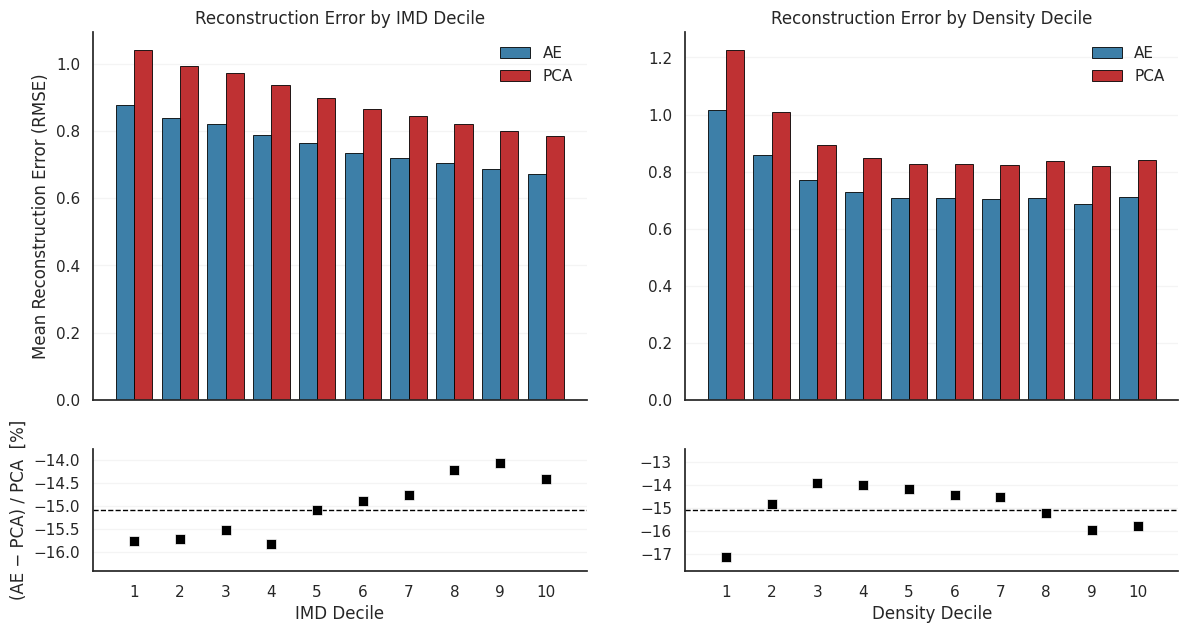


=== Reconstruction Error by Group (OAC SuperGroup) [metric: mean] ===
Error Type                                             AE       PCA
Supergroup_codename                                                
1 - Retired Professionals                        0.629201  0.750261
2 - Suburbanites and Peri-Urbanites              0.647285  0.759525
3 - Multicultural and Educated Urbanites         1.039711  1.245676
4 - Low-Skilled Migrant and Student Communities  0.977784  1.168617
5 - Ethnically Diverse Suburb-an Professionals   0.752796  0.875254
6 - Baseline UK                                  0.778348  0.890665
7 - Semi- and Un-Skilled Workforce               0.673541  0.799192
8 - Legacy Communities                           0.864437  1.028308

--- Percentage Increase in Error (OAC SuperGroup): 8 - Legacy Communities → 1 - Retired Professionals ---
AE: -27.21%
PCA: -27.04%

--- Summary ---
AE shows a 27.21% decrease in error from 8 - Legacy Communities to 1 - Retired Professionals.
PCA sh

/tmp/ipykernel_351963/3955161348.py:174: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=7)
/tmp/ipykernel_351963/3955161348.py:174: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=7)
/tmp/ipykernel_351963/3955161348.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


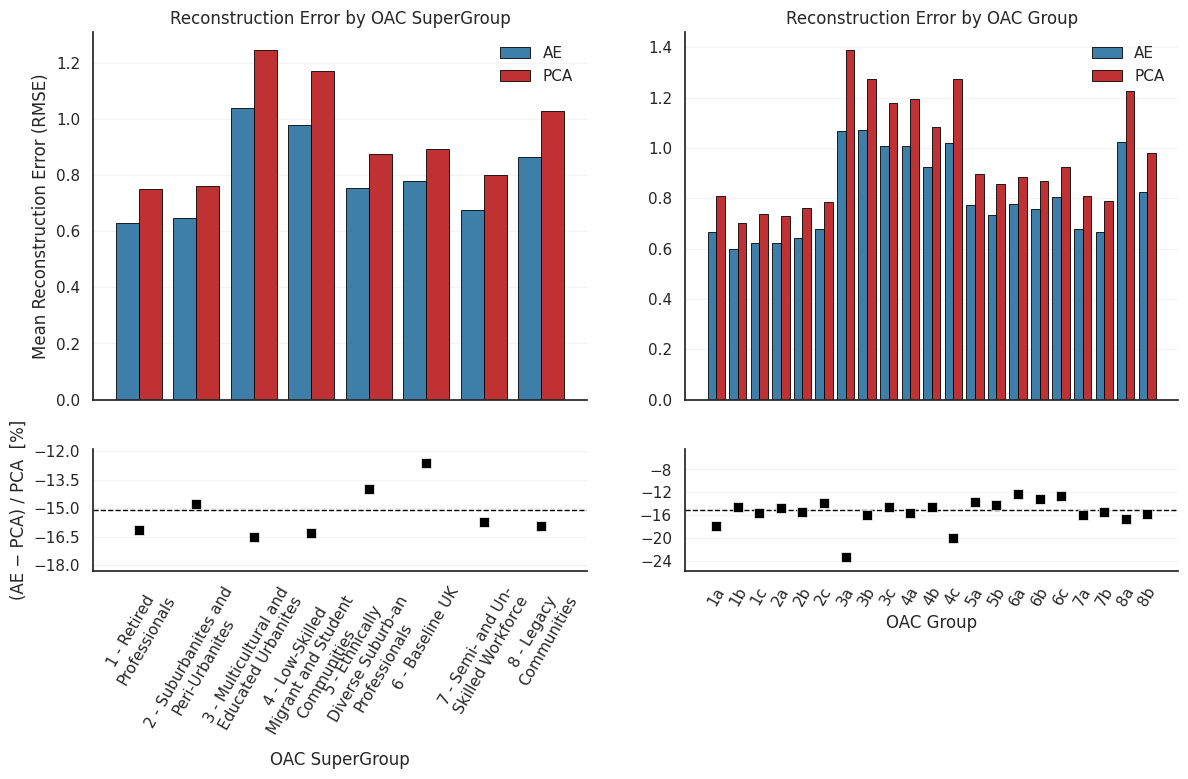

In [23]:
# Ensure output directory exists
os.makedirs("plots/pub_plots", exist_ok=True)

# --- Mean RMSE: IMD (IoD 2025) / Density ---
fig, axes = plot_side_by_side_charts(
    reco_err, pca_reco_err,
    "IMD", "Density_decile",
    "IMD Decile", "Density Decile",
    "Reconstruction Error", {},
    bottleneck=bottleneck, rotation=0,
    diff_style='point_only', marker='s',
    print_means=True
)
plt.savefig(f"plots/pub_plots/iod2025_mean_rmse_IMD_Density_{bottleneck}d.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Mean RMSE: OAC Supergroup / Group ---
fig, axes = plot_side_by_side_charts(
    reco_err, pca_reco_err,
    "Supergroup_codename", "Group",
    "OAC SuperGroup", "OAC Group",
    "Reconstruction Error", {},
    bottleneck=bottleneck, rotation=60,
    wrapped_labels=True,
    diff_style='point_only', marker='s',
    print_means=True
)
plt.savefig(f"plots/pub_plots/iod2025_mean_rmse_OAC_{bottleneck}d.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_351963/159417773.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


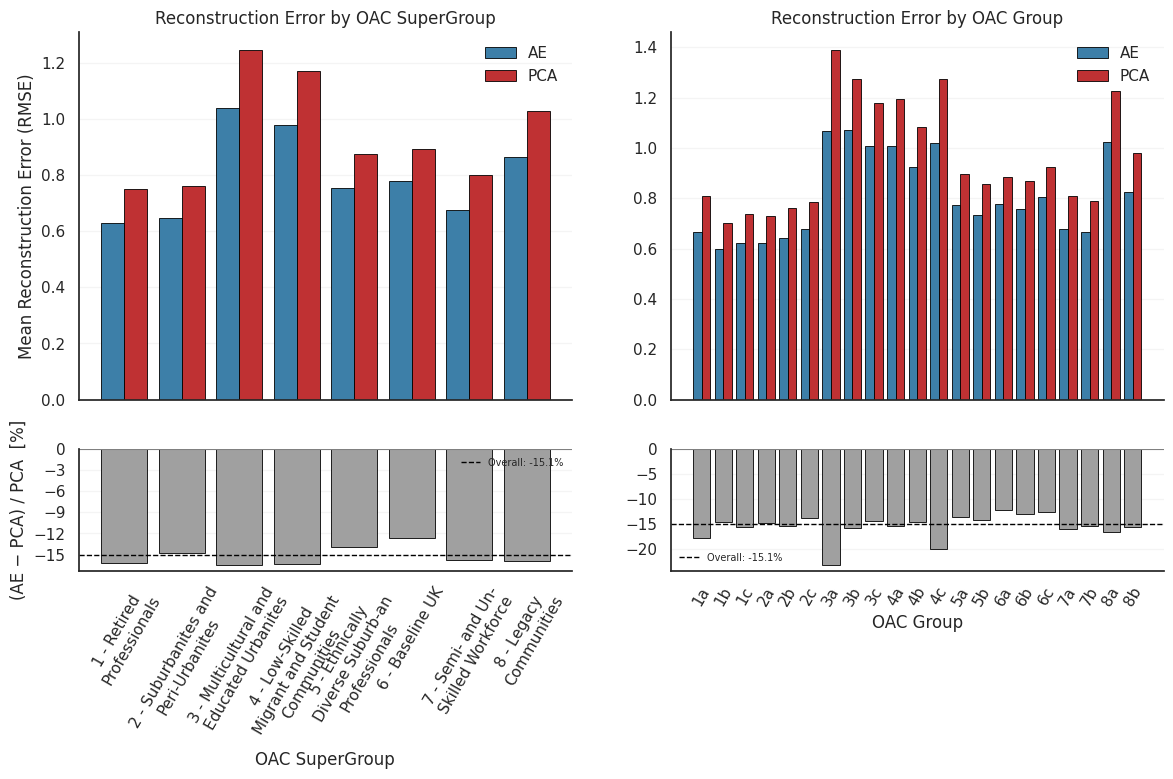

In [14]:
# Plot OAC Supergroup and Group (saved to pub_plots)
fig, axes = plot_side_by_side_charts(
    reco_err, 
    pca_reco_err, 
    "Supergroup_codename", 
    "Group", 
    "OAC SuperGroup", 
    "OAC Group", 
    "Reconstruction Error", 
    {},
    bottleneck=bottleneck, 
    rotation=60,
    wrapped_labels=True
)
plt.savefig(f"plots/pub_plots/iod2025_run{selected_run_idx}_OAC_bottleneck_{bottleneck}.png", dpi=300, bbox_inches='tight')
plt.show()

## 4b. Global RMSE per Segment

Same groupings as above, but using **Global RMSE** = `sqrt(mean(RMSE²))` within each segment
rather than `mean(RMSE)`. This up-weights OAs with high error, revealing segments where
reconstruction quality is driven by outlier OAs.


=== Reconstruction Error by Group (IoD 2025 IMD Decile) [metric: global_rmse] ===
Error Type        AE       PCA
IMD                           
1           0.912732  1.090744
2           0.872382  1.047415
3           0.856290  1.025715
4           0.824364  0.993525
5           0.795445  0.947405
6           0.766358  0.912617
7           0.749539  0.893227
8           0.734066  0.864476
9           0.711938  0.837716
10          0.692409  0.817848

--- Percentage Increase in Error (IoD 2025 IMD Decile): 10 → 1 ---
AE: 31.82%
PCA: 33.37%

--- Summary ---
AE shows a 31.82% increase in error from 10 to 1.
PCA shows a 33.37% increase in error from 10 to 1.

Mean percentage change across all error types: 32.59%

=== Reconstruction Error by Group (Density Decile) [metric: global_rmse] ===
Error Type            AE       PCA
Density_decile                    
1               1.061172  1.298979
2               0.888513  1.053330
3               0.793203  0.926764
4               0.750077  0.

/tmp/ipykernel_351963/159417773.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


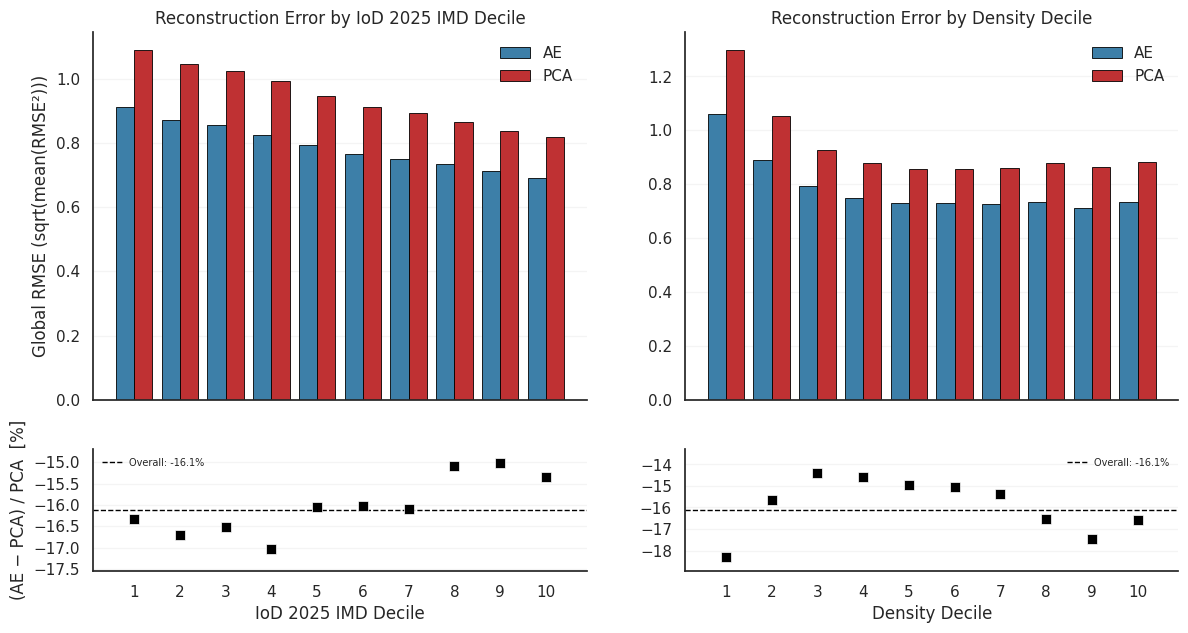


=== Reconstruction Error by Group (OAC SuperGroup) [metric: global_rmse] ===
Error Type                                             AE       PCA
Supergroup_codename                                                
1 - Retired Professionals                        0.641991  0.773751
2 - Suburbanites and Peri-Urbanites              0.661386  0.781773
3 - Multicultural and Educated Urbanites         1.077368  1.305616
4 - Low-Skilled Migrant and Student Communities  1.009431  1.221245
5 - Ethnically Diverse Suburb-an Professionals   0.773489  0.917479
6 - Baseline UK                                  0.796659  0.921682
7 - Semi- and Un-Skilled Workforce               0.684366  0.815857
8 - Legacy Communities                           0.891226  1.062856

--- Percentage Increase in Error (OAC SuperGroup): 8 - Legacy Communities → 1 - Retired Professionals ---
AE: -27.97%
PCA: -27.20%

--- Summary ---
AE shows a 27.97% decrease in error from 8 - Legacy Communities to 1 - Retired Professionals.

/tmp/ipykernel_351963/159417773.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


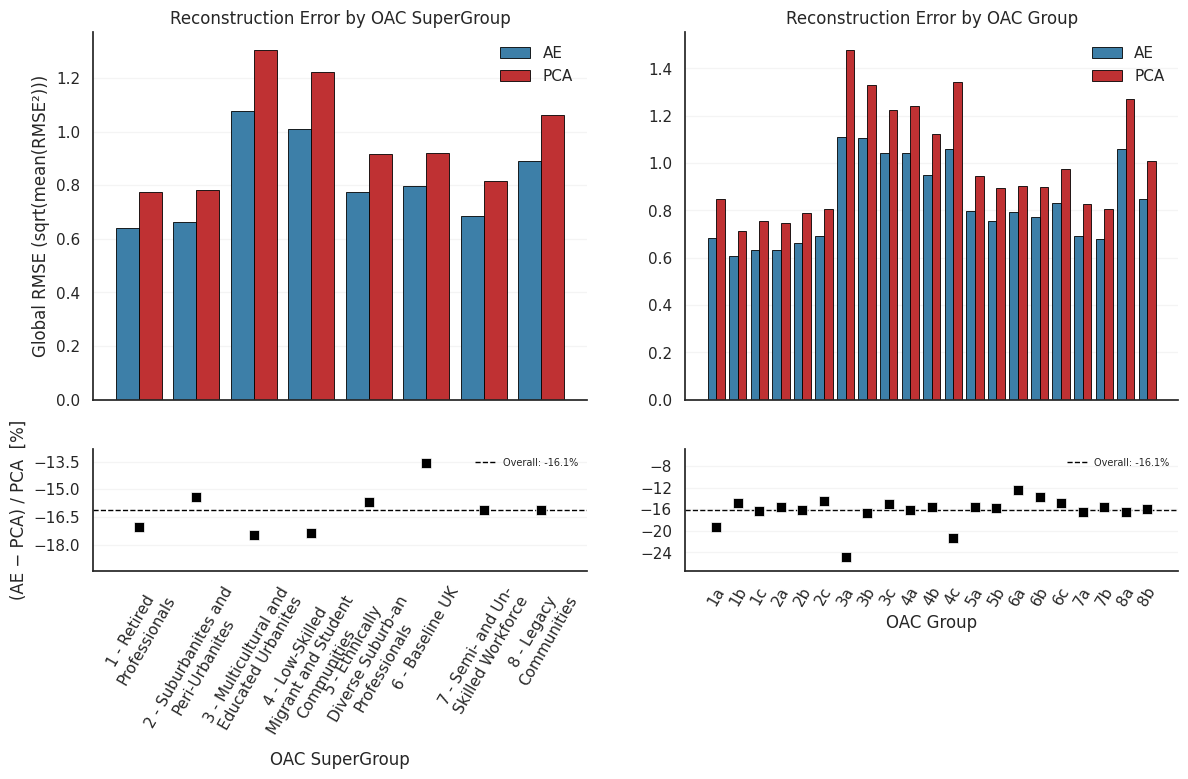

In [15]:
# --- Global RMSE: IMD (IoD 2025) / Density ---
fig, axes = plot_side_by_side_charts(
    reco_err, pca_reco_err,
    "IMD", "Density_decile",
    "IoD 2025 IMD Decile", "Density Decile",
    "Reconstruction Error", {},
    bottleneck=bottleneck, rotation=0,
    metric='global_rmse',
    diff_style='point_only', marker='s',
    print_means=True
)
plt.savefig(f"plots/pub_plots/iod2025_global_rmse_IMD_Density_{bottleneck}d.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Global RMSE: OAC Supergroup / Group ---
fig, axes = plot_side_by_side_charts(
    reco_err, pca_reco_err,
    "Supergroup_codename", "Group",
    "OAC SuperGroup", "OAC Group",
    "Reconstruction Error", {},
    bottleneck=bottleneck, rotation=60,
    wrapped_labels=True,
    metric='global_rmse',
    diff_style='point_only', marker='s',
    print_means=True
)
plt.savefig(f"plots/pub_plots/iod2025_global_rmse_OAC_{bottleneck}d.png", dpi=300, bbox_inches='tight')
plt.show()

## 5. Generate Spatial Data for Mapping

In [16]:
"""
This section compares reconstruction errors between AE (selected run) and PCA at two geographic levels:
  1. Output Area (OA21CD)
  2. Middle Layer Super Output Area (MSOA21CD)

Steps:
- Merge and align error data
- Attach geographic boundaries (OAs and MSOAs)
- Calculate % difference in error
- Export the results to Parquet files for mapping
"""

# STEP 1: Merge reconstruction errors at OA level
merged = reco_err.merge(pca_reco_err, on="OA21CD", suffixes=("", "_pca"))

# Remove duplicated columns from pca_reco_err unless they're actual PCA error columns
merged = merged[[col for col in merged.columns if not col.endswith("_pca") or col.startswith("pca_err")]]

# STEP 2: Load OA boundaries and merge with error data
oa_gdf = gpd.read_parquet("../data/geofiles/oabounds_2021approx.parquet")[["OA", "geometry"]]
oa_gdf = oa_gdf.rename(columns={"OA": "OA21CD"})  # match OA code field name
merged = oa_gdf.merge(merged, on="OA21CD", how="right")  # keep only OAs with error data

# STEP 3: Calculate % difference in error
merged[f"perc_diff_{bottleneck}"] = (
    (merged[f"reco_err_{bottleneck}"] - merged[f"pca_err_{bottleneck}"]) / merged[f"pca_err_{bottleneck}"] * 100
)

# STEP 4: Format and export OA-level results
merged.set_index("OA21CD", inplace=True)
merged = merged.round(5)
os.makedirs("plots/maps", exist_ok=True)
out_oa = f"plots/maps/iod2025_run{selected_run_idx}_error_diff_by_OA_{bottleneck}d.parquet"
merged.to_parquet(out_oa)
print(f"Saved OA-level results to {out_oa}")

Saved OA-level results to plots/maps/iod2025_run5_error_diff_by_OA_100d.parquet


In [17]:
# STEP 5: Aggregate to MSOA level
# Keep only error columns and MSOA codes for aggregation
merged_for_msoa = merged[[col for col in merged.columns if col.startswith("reco_err") or col.startswith("pca_err") or col == "MSOA21CD"]]

# Group by MSOA and compute mean error values
msoa = merged_for_msoa.groupby("MSOA21CD").mean().reset_index()

# Recompute % difference in error at MSOA level
msoa[f"perc_diff_{bottleneck}"] = (
    (msoa[f"reco_err_{bottleneck}"] - msoa[f"pca_err_{bottleneck}"]) / msoa[f"pca_err_{bottleneck}"] * 100
)

# STEP 6: Load MSOA boundaries and merge with error data
msoa_gdf = gpd.read_file(
    "../data/geofiles/Middle_layer_Super_Output_Areas_(December_2021)_Boundaries_EW_BFE_(V8)_and_RUC"
)[["MSOA21CD", "geometry"]]
msoa = msoa_gdf.merge(msoa, on="MSOA21CD", how="right")

# STEP 7: Export MSOA-level GeoDataFrame
out_msoa = f"plots/maps/iod2025_run{selected_run_idx}_error_diff_by_MSOA_{bottleneck}d.parquet"
msoa.to_parquet(out_msoa)
print(f"Saved MSOA-level results to {out_msoa}")

Saved MSOA-level results to plots/maps/iod2025_run5_error_diff_by_MSOA_100d.parquet


In [18]:
# Calculate PCA quantile breaks for MSOA error mapping
# Range spans min/max across both AE and PCA errors

ae_vals = msoa[f"reco_err_{bottleneck}"]
pca_vals = msoa[f"pca_err_{bottleneck}"]

overall_min = min(ae_vals.min(), pca_vals.min())
overall_max = max(ae_vals.max(), pca_vals.max())

print(f"MSOA error range (AE):  {ae_vals.min():.4f}% to {ae_vals.max():.4f}%")
print(f"MSOA error range (PCA): {pca_vals.min():.4f}% to {pca_vals.max():.4f}%")
print(f"Combined range:         {overall_min:.4f}% to {overall_max:.4f}%")

# PCA quintile breaks (to be used for both AE and PCA maps)
pca_quantiles = pca_vals.quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0])
print(f"\nPCA quintile breaks:")
for q, v in pca_quantiles.items():
    print(f"  {q:.0%}: {v:.4f}%")

# Construct break values: use PCA quintiles but clip to combined min/max
breaks = [overall_min] + list(pca_quantiles.values[1:-1]) + [overall_max]
print(f"\nSuggested map breaks (for QGIS): {[round(b, 4) for b in breaks]}")

MSOA error range (AE):  0.5329% to 1.6423%
MSOA error range (PCA): 0.6082% to 2.8518%
Combined range:         0.5329% to 2.8518%

PCA quintile breaks:
  0%: 0.6082%
  20%: 0.7411%
  40%: 0.7926%
  60%: 0.8634%
  80%: 1.0272%
  100%: 2.8518%

Suggested map breaks (for QGIS): [np.float64(0.5329), np.float64(0.7411), np.float64(0.7926), np.float64(0.8634), np.float64(1.0272), np.float64(2.8518)]


In [19]:
#number of MSOAs where AE error is greater than PCA error
n_msoa_ae_greater = len(msoa[msoa[f"reco_err_{bottleneck}"] > msoa[f"pca_err_{bottleneck}"]])
print(f"\nNumber of MSOAs where AE error > PCA error: {n_msoa_ae_greater} out of {len(msoa)} ({n_msoa_ae_greater / len(msoa) * 100:.2f}%)")


Number of MSOAs where AE error > PCA error: 0 out of 6856 (0.00%)


## 6. Summary

In [20]:
print("=" * 80)
print(f"SUMMARY: Error by Geography — IoD 2025, England Only ({run_label})")
print("=" * 80)

print(f"\nConfiguration:")
print(f"  Bottleneck dimension: {bottleneck}D")
print(f"  Training: 500 epochs, linear scaling")
print(f"  Total retraining runs available: {n_runs}")
print(f"  Selected run: {run_label}")
print(f"  IMD source: English IoD 2025 (LSOA 2021 codes)")
print(f"  Geography: England only ({len(reco_err)} OAs)")

print(f"\nReconstruction Error Comparison (England only):")
print(f"  {'':25s} {'Global RMSE':>12s}  {'Mean per-OA':>12s}")
print(f"  {'':-<25s} {'':-<12s}  {'':-<12s}")
print(f"  {f'AE ({run_label})':<25s} {rmse_per_run_eng[selected_run_idx]*100:>11.4f}%  {mean_oa_rmse_per_run_eng[selected_run_idx]*100:>11.4f}%")
print(f"  {'PCA':<25s} {global_rmse_pca:>11.4f}%  {mean_oa_rmse_pca:>11.4f}%")

print(f"\n  Improvement vs PCA (Global RMSE):")
print(f"    Selected AE: {(global_rmse_pca - rmse_per_run_eng[selected_run_idx]*100) / global_rmse_pca * 100:.2f}%")
print(f"  Improvement vs PCA (Mean per-OA RMSE):")
print(f"    Selected AE: {(mean_oa_rmse_pca - mean_oa_rmse_per_run_eng[selected_run_idx]*100) / mean_oa_rmse_pca * 100:.2f}%")

print(f"\nOutput Files:")
print(f"  Plots: plots/pub_plots/iod2025_*.png")
print(f"  Spatial data: plots/maps/iod2025_run{selected_run_idx}_error_diff_*.parquet")
print("=" * 80)

SUMMARY: Error by Geography — IoD 2025, England Only (median (Run 5))

Configuration:
  Bottleneck dimension: 100D
  Training: 500 epochs, linear scaling
  Total retraining runs available: 10
  Selected run: median (Run 5)
  IMD source: English IoD 2025 (LSOA 2021 codes)
  Geography: England only (178605 OAs)

Reconstruction Error Comparison (England only):
                             Global RMSE   Mean per-OA
  ------------------------- ------------  ------------
  AE (median (Run 5))            0.7950%       0.7618%
  PCA                            0.9478%       0.8972%

  Improvement vs PCA (Global RMSE):
    Selected AE: 16.12%
  Improvement vs PCA (Mean per-OA RMSE):
    Selected AE: 15.09%

Output Files:
  Plots: plots/pub_plots/iod2025_*.png
  Spatial data: plots/maps/iod2025_run5_error_diff_*.parquet
